# Companies House - Logistic Regression

This script concentrates on creating and running the logistic regression model using data created and saved in the previous script.
We saved the cleaned and prepared dataset earlier as a Parquet file in a previous script and saved it loacally for use in this and other scripts to enable faster, more secure loading as the data is **~5.5million rows**.

This script loads the data into a DataFrame and uses it to create a logistic regression model that can for predicting the probability that a company is likely to file late Companies House accounts when considering their company structure and governance features and comparable to the late filing history of other companies with similar features.

## 1. Libraries and Data Loading

In [3]:
# Data handling tools
import pandas as pd
import numpy as np

# Modelling preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Logistic Regression model running tools
from sklearn.linear_model import LogisticRegression

# Evaluation Metric tools
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    roc_auc_score,
    recall_score,
    f1_score,
    roc_curve,
    precision_recall_curve,
    auc
)

# Visualisation Tools
import matplotlib.pyplot as plt
import seaborn as sns

#### Load the final modelling dataset from its local file storage path.

In [4]:
# Load the final modelling dataset
data_path = r"C:\Users\AT355573\Documents\DS_Assignments\Companies House\data_processed\model_ready_data.parquet"
df = pd.read_parquet(data_path)

df.head(10)

,company_category,company_age_when_acc_due,industry,registered_country,psc_count,has_corporate_psc,has_foreign_psc,recent_psc_change,overdue
0,LTD,10–20,Public & Non‑Market,KNOWN UK,2,0,1,0,0
1,LTD,5–10,Information & Communication,UNKNOWN,1,0,0,0,0
2,LTD,0–2,Health & Social Care,KNOWN UK,1,0,0,1,0
3,LTD,2–5,"Professional, Scientific & Tech",KNOWN UK,1,0,1,0,0
4,LTD,5–10,Information & Communication,KNOWN UK,1,0,0,0,0
5,LTD,5–10,Information & Communication,KNOWN UK,1,0,1,0,0
6,LTD,5–10,Real Estate,KNOWN UK,2,0,1,0,0
7,LTD,10–20,"Professional, Scientific & Tech",KNOWN UK,3,0,0,0,1
8,LTD,10–20,"Professional, Scientific & Tech",UNKNOWN,2,0,0,0,0
9,LTD,20+,Other Services,UNKNOWN,1,0,0,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5506694 entries, 0 to 5506693
Data columns (total 9 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   company_category          category
 1   company_age_when_acc_due  category
 2   industry                  category
 3   registered_country        category
 4   psc_count                 int64   
 5   has_corporate_psc         int8    
 6   has_foreign_psc           int8    
 7   recent_psc_change         int8    
 8   overdue                   int8    
dtypes: category(4), int64(1), int8(4)
memory usage: 84.0 MB


Initial inspection shows that all expected columns are present, and in the correct format (categorical and numeric), the variables are ready for analysis.

## 2. Check the Balance of the Target Variable
Here our target variable is *"overdue"* which describes when a company has filed on-time (0) or is overdue (1). Let's define our target variable and visualise to get a sense of distribution between overdue and on-time.

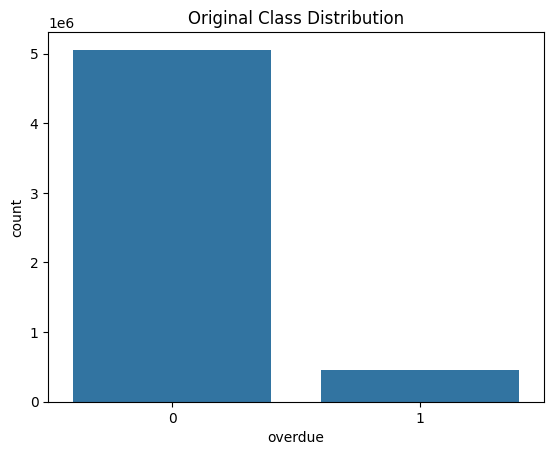

Original number of rows:  5506694
overdue
0    0.917908
1    0.082092
Name: proportion, dtype: float64


In [6]:
# Define the target variable, 'overdue' is the variable we want to predict (0 = on-time, 1 = late).
target = "overdue"

# Visualise the target variable
sns.countplot(x=target, data=df)
plt.title("Original Class Distribution")
plt.show()

print("Original number of rows: ", len(df))

print(df[target].value_counts(normalize = True))

The diagram above shows that the target variable has a large imbalance favouring 'on-time' **(91.8%)** over 'late/overdue' **(8.2%)**.

Logistic regression performs best on balanced data, this will be dealt with by applying **Synthetic Minority Oversampling Technique (SMOTE)** when building the model pipeline ***(in section 5)***. SMOTE synthesises new minority-class examples so that the number of examples of 'overdue' matches the number of examples of 'on-time' (the majority class). This will ensure that the logisitc regression model receives equal representation for both classes **during training**.

SMOTE is very resource intensive when datasets contain a large number of categories and large number of observations like in the Companies House data we are using, which is millions of rows. So taking a sample of the data is the best option, which we do next. Stratified sampling is conducted to ensure that the proportion of late filing companies is not over or under represented in the newly created sample dataset.

### *** Warning!! Need to talk about class_weight here for addressing the imbalance in the data*** 



## 3. Reduce the Dataset Size

**Stratified Sampling:**
- **Efficiencies:** The large size of the starting dataset **(~5.5m)** would be resource intensive for both SMOTE and logistic regression therefore stratified sampling would speed up the processes without compromising the distribution late filings **(8.2%)**.
- **Proportions:** When splitting the data we stratify on the target variable counts to keep the **proportion** of overdue companies the same in both sets, and use a seed to ensure the results are replicable when running the process again using the same dataset. This also preserves the real-world distribution in our data to ensure it reflects our original population.

We will use a strafied sample size of **~25%** of the original population size.<br>
- Starting population = **~5.5**million;
- **75%** discarded data = **~4.125**million;
- **25%** sample data **~1.375**million.

**NOTE:** The full sample should be used in a production model as maximum predictive accuracy is required and there is likely a much higher computational power available.

In [7]:
# Create the 25% stratified sample
df_sample, df_discard = train_test_split(
    df, 
    train_size = 0.25,        # train_size decides the proportion retained to create the sample dataset
    stratify = df[target],    # stratify defines which column should be used to stratify the data, note: y was defined as the target variable earlier
    random_state = 42         # random_state acts as a seed to ensure results are replicable when running the code again with the same data.
)

print("Sample dataset shape: ", df_sample.shape)
print("Sample number of rows: ", len(df_sample))
print("Discarded number of rows: ", len(df_discard))

Sample dataset shape:  (1376673, 9)
Sample number of rows:  1376673
Discarded number of rows:  4130021


The figures above show that the starting population has now been reduced down to **25%** of it's original size, which will make the next stages more efficient. <br>
Let's confirm that the balance from the original population was not distorted in the sample.

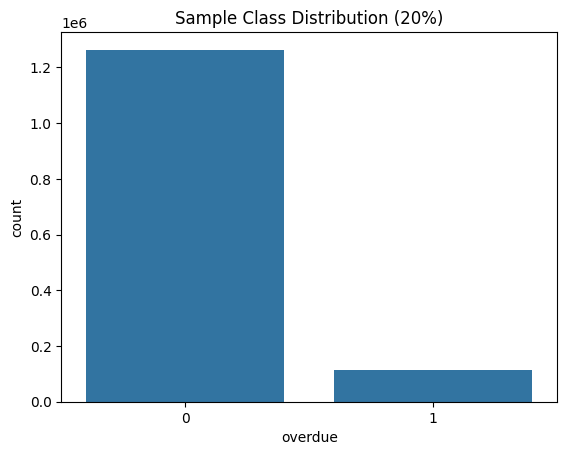

value,count,percentage
0,1263659,91.790788
1,113014,8.209212


In [8]:
# Value counts (absolute frequencies)
value_counts = df_sample[target].value_counts()
# Percentages
percentages = df_sample[target].value_counts(normalize=True) * 100

# Combine into a single DataFrame
df_sample_stats = pd.DataFrame({
    'count': value_counts,
    'percentage': percentages,
})

# Optional: Reset index for cleaner column names
df_sample_stats = df_sample_stats.reset_index()
df_sample_stats.columns = ['value', 'count', 'percentage']

# Visualise the target varaible in the sample population
sns.countplot(x=target, data=df_sample)
plt.title("Sample Class Distribution (20%)")
plt.show()

# Format the table from above for clean display
df_sample_stats.style.hide(axis="index")


This shows that we still have a **91.8%** (on-time) and **8.2%** (late) split, confirming that sampling did not distort the proportions. <br>
Instead of our original **5.5m** rows we now have **~1.38m (1.26m + 0.11m)**

## 4. Define Features and Target

Separate out the predictors (x) and the target variable (y), so that ....
#### Must write a reason why in here later.

In [9]:
x = df_sample.drop(columns=[target])     # define x which contains all predictor/feature variables.
y = df_sample[target]                    # define y which contains only the target variable

## 5. Train-Test Split (Stratified)

Now we split the data into two sectors, one to be used as a training dataset and one as a testing dataset. The training of the model should be done on unseen data so splitting the data is done before scaling and one-hot encoding to reduce the data leakage risk.

**Data Leakage:**
- **Scaling:** The mean and standard deviation used in *StandardScaler* would be computed on the entire dataset, which would leak information from the test set into the training process.
- **One-hot Encoding:** If a categorical variable has a rare category that only exists in the test set then doing one-hot encoding before the splitting could intriduce categories into the training that wouldn't otherwise. Or conversely, the model could see some categories that only exist in the test dataset during training.

Splitting the data into testing and training data should should be done with care to ensure that there is a representation of on-time and late in both the datasets, therefore we will stratify on the target variable 'overdue'.

We will use **80%** of the data as the training dataset and **20%** as the testing dataset so that the model has a larger proportion of the data to train on and a smaller proportion to test on. Having more data to train on gives the model more information to work with and increases the likelihood of it performing well on the test datast.

In [10]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size = 0.2,
    stratify = y,
    random_state = 42
)

Now we check the distribution of the train and test data.

In [11]:
print("Train: \n", y_train.value_counts(normalize=True))
print("Train number of rows: ", len(y_train))
print ("\n")
print("Test: \n", y_test.value_counts(normalize=True))
print("Test number of rows: ", len(y_test))

Train: 
 overdue
0    0.917908
1    0.082092
Name: proportion, dtype: float64
Train number of rows:  1101338


Test: 
 overdue
0    0.917907
1    0.082093
Name: proportion, dtype: float64
Test number of rows:  275335


Here we can see that both the test and train data demonstrate the same proportionality of 'on-time' to 'overdue' as the original population, and together the number of rows adds up to the size of the sample dataset from earlier meaning that there was no bias introduced in either the sampling of the original dataset or in the splitting of the sample in the test-train split of the sample. **train (1,101,338) + test (275,335) = sample (1,376,673)** <br><br>
We can be confident in our training data and testing data and consider it as representative of the original population in terms of the 'overdue' distribution, but we must remember that the distributions of each feature variable in the test/train data and our sample data may not represent the same distribution as the original population.

## 6. Preprocessing (Encoding categorical variables and Scaling numeric variables)
- Logistic regression requires numeric input, it cannot work directly with text categories, *OneHotEncoder* turns variables containing categorical data into multiple binary columns which can then be used in the logistic regression model.  **NOTE:** Using *drop="first"* avoids multicollinearity as otherwise all of the one-hot encoded columns together will be able to directly predict the original column.
- *StandardScaler* ensures each feature has a mean of 0 and a standard deviation of 1. This prevents features with larger numeric ranges from dominating model training in logistic regression, improving model stability.

Next we identify which columns are categorical and which are numeric and then use OneHotEncoder on the list of categorical features and StandardScaler on the list of numeric features.

In [12]:
# Identify categorical and numeric columns.
categorical_cols = x.select_dtypes(include="category").columns.tolist()
numeric_cols = x.select_dtypes(include=["int64", "int8", "float64"]).columns.tolist()
print("Categorical Columns: ", categorical_cols)
print("Numerical Columns:   ", numeric_cols)

Categorical Columns:  ['company_category', 'company_age_when_acc_due', 'industry', 'registered_country']
Numerical Columns:    ['psc_count', 'has_corporate_psc', 'has_foreign_psc', 'recent_psc_change']


In [13]:
# Transform the columns using OneHotEncoder and StandardScaler
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)    # drop="first" avoids multicollinearity.
    ]
)

## 7. Model Building
Here we will build 3 model pipelines to be used on the data for training a model. We will compare the outcomes of all three to identify which is best for our data.

##### A - Baseline Model
The pipeline will keep the preprocessing and modelling together, to ensure that the same steps are applied consistently during training and testing, and it avoids having to manually do the transformations twice.

In [14]:
pipeline_baseline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]
)

# Fit the model to our training data, the model learns the relationship between the features and the target.
pipeline_baseline.fit(x_train, y_train)

y_pred_base = pipeline_baseline.predict(x_test)
y_prob_base = pipeline_baseline.predict_proba(x_test)[:,1]

##### B - Class Weight Model
This model penalises misclassification of late filings, and adjusts its learning without changing the data.

In [15]:
pipeline_weighted = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight='balanced',
            random_state=42
        ))
    ]
)

# Fit the model to our training data, the model learns the relationship between the features and the target.
pipeline_weighted.fit(x_train, y_train)

y_pred_weighted = pipeline_weighted.predict(x_test)
y_prob_weighted = pipeline_weighted.predict_proba(x_test)[:, 1]

##### C - SMOTE Model
This pipeline creates sythetic examples of late filing companies (the minority class of the population) which will be applied to the training data via a pipeline to avoid data leakage.

In [16]:
pipeline_smote = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=42
        ))
    ]
)

# Fit the model to our training data, the model learns the relationship between the features and the target.
pipeline_smote.fit(x_train, y_train)

y_pred_smote = pipeline_smote.predict(x_test)
y_prob_smote = pipeline_smote.predict_proba(x_test)[:, 1]

## 8. Model Evaluation Table
Create a table allowing us to evaluate and compare all of the models against each other.
Here we will focus on Recall and Precision.
- **Recall:** Detection of late filers
- **Precision:** False positive

In [17]:
results = pd.DataFrame({
    'Model': ['Baseline', 'Class Weight', 'SMOTE'],
    'Precision': [
        precision_score(y_test, y_pred_base),
        precision_score(y_test, y_pred_weighted),
        precision_score(y_test, y_pred_smote)
        ],
    'Recall': [
        recall_score(y_test, y_pred_base),
        recall_score(y_test, y_pred_weighted),
        recall_score(y_test, y_pred_smote)
        ],
    'F1 Score': [
        f1_score(y_test, y_pred_base),
        f1_score(y_test, y_pred_weighted),
        f1_score(y_test, y_pred_smote)
        ],
    'ROC_AUC': [
        roc_auc_score(y_test, y_pred_base),
        roc_auc_score(y_test, y_pred_weighted),
        roc_auc_score(y_test, y_pred_smote)
    ]
})

results

,Model,Precision,Recall,F1 Score,ROC_AUC
0,Baseline,0.830979,0.078087,0.142759,0.538333
1,Class Weight,0.142789,0.753838,0.240099,0.674548
2,SMOTE,0.143794,0.755519,0.241605,0.676592


Let's represent the 3 models in a clustered column chart to gain a visual sense of the numbers in the table above. This shows the trade-offs between the 3 models.

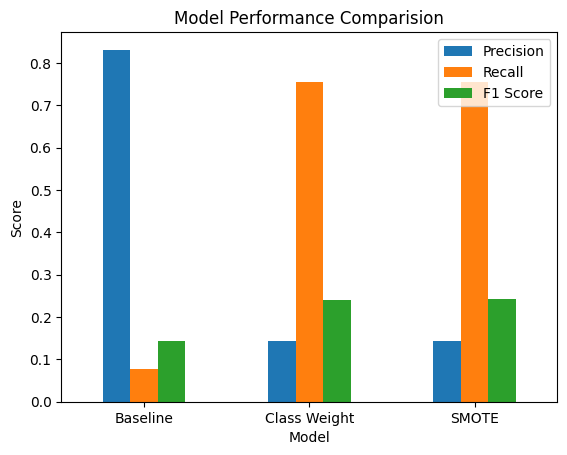

In [18]:
comparison_chart = results.set_index('Model')
comparison_chart[['Precision', 'Recall', 'F1 Score']].plot(kind='bar')

plt.title("Model Performance Comparision")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()

Precision measures the proportion of correctly identified late filing companies among all of the late filing companies. Higher precision indicates fewer false positives, meaning fewer on-time companies were incorrectly flagged as late.

Recall measures the proportion of all the companies that actually filed late that the model predicted would file late. Higher recall indicates that there is more late filers identified but the cost of that is that more on-time companies are identified as filing late.

F1 is a balance between precision and recall. It penalises models that have high precision but low recalls, or high recall but low precision. It only scores low in models were both precision and recall are good.

For this project recall is more important because not identifying late filers may be regulatory failures but identifying false positives (those that were on-time but incorrectly predicted as late) may create extra work investigating companies where they are flagged as non-compliant but they are actually compliant. Ultimately there is a trade-off between correctly identifying more late filers and creating an admin burden. It would depend on the final use case of the model as to whether extra administrative effort is worth the sacrifice.

The chart and table show that:
- Precision is much higher in the baseline model than the other two models, but that comes with a very low recall value, which can be interpretted as the model very rarely detecting late filing companies.
- The recall dramatically improves for both the class-weight model and SMOTE but with a large drop in precision. This can be inpterpretted as both models finding late companies but with less accuracy, so of all the companies these models flagged as late only around 14% of them truly were late.
- The F1 score is lower in the Baseline model and higher in the other 2 models, meaning that the balance between precision and recall is better in SMOTE and class-weighting than in the Baseline model.

In practical terms, rebalancing the sample population using both SMOTE and class-weighting models was worth it as both are good at identifying companies likely to file late, even if they occasionally flag some that won't. For Companies House or any regulatory body, high recall may be far more valuable than high precision as catching as many risky companies as possible may be the ultimate goal.

This information leads us to the conclusion that SMOTE or class-weighting is the better option.

Let's look at the ROC Curve to further assess.

## 9. ROC Curve
Let's plot the ROC Curve to evaluate the discriminatory ability of the models.
**Note:** A higher curve = a better model

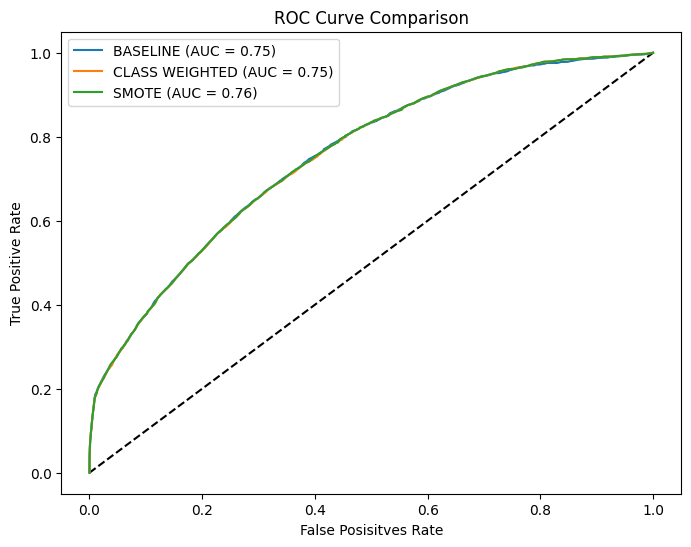

In [19]:
fpr_base, tpr_base, _ = roc_curve(y_test, y_prob_base)
fpr_weighted, tpr_weighted, _ = roc_curve(y_test, y_prob_weighted)
fpr_smote, tpr_smote, _ = roc_curve(y_test, y_prob_smote)

plt.figure(figsize=(8,6))

#plot diagonal dashed line (random classifier)
plt.plot([0,1],[0,1], 'k--')

roc_auc_base = roc_auc_score(y_test, y_prob_base)
roc_auc_weighted = roc_auc_score(y_test, y_prob_weighted)
roc_auc_smote = roc_auc_score(y_test, y_prob_smote)

plt.plot(fpr_base, tpr_base, label=f'BASELINE (AUC = {roc_auc_base:.2f})')
plt.plot(fpr_weighted, tpr_weighted, label=f'CLASS WEIGHTED (AUC = {roc_auc_weighted:.2f})')
plt.plot(fpr_smote, tpr_smote, label=f'SMOTE (AUC = {roc_auc_smote:.2f})')

plt.xlabel("False Posisitves Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

A perfect classification model would hug the top left corner with a high true-positive rate early on.
A diagonal line was included in the plot to represent the performance of a random classifier. All models performing above this line deomstrate predictive capability.

THe ROC curve shows how well each model can discriminate between late-filing companies and on-time ones without relying on any single threshold. In our case, all three curves sit well above the diagonal "random guess" line, which meant all models are good at ranking companies by risk. The curves are very close together (practically on top of each other) with AUC values of 0.75-0.76, which shows that class weighting and SMOTE don't change the overall ranking ability much. They mainly affect how many late companies the model chooses to flag, not how well it separates the two groups overall.

At this point we choose a model to take forwards.
**Baseline:** Reject because it was very poor at predicting late companies even though it's precision was high.
**Class Weight:** This is a strong contender as it massivley improved recall and F1 from the baseline model.
**SMOTE:** Another strong contender as it is almost identical to class weighting but with slightly higher AUC.

**Decision:** SMOTE as it has the highest AUC, highest recall, and highest F1 and a higher precision than class weighting. Oversampling the minority class improved the model's ability to detect late filings.

Based on this decision we will produce the confusion matrix for the SMOTE model.

## 10. Confusion Matrix
This shows the real-world impact, which is important for regulatory interpretation.

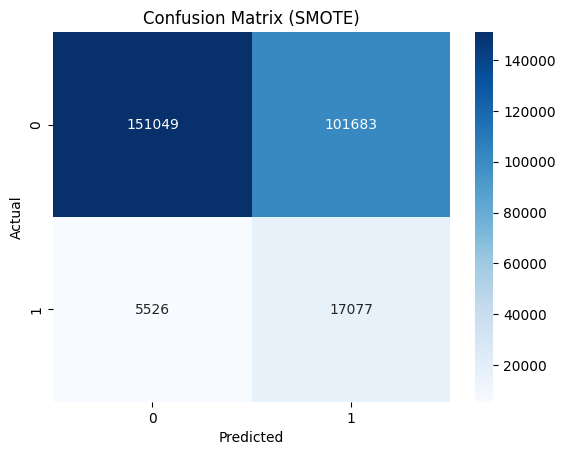

In [20]:
conf_matrix = confusion_matrix(y_test, y_pred_smote)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix (SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

**True Negatives:** 151,049  -  **False Positives:** 101,683
**False Negatives:**  5,526  -  **True Negatives:**   17,077

This shows that the model is very good at finding late-filing companies (high true positives) and misses relatively few of them (low false negatives), which matches the high recall shown earlier **(~0.756)**

As the model is trying hard to catch late filers, it also produces a large number of false positives, companies predicted to be late filers but who actually file on time. Which is to be expected given the imbalance between late and on-time in our model, predicting a rare event such as filing late brings with it a lot of falsely predicted late-filing companies.

Overall this confusion matrix shows that the SMOTE model is effective at identifying late filer, even though it flags many on-time companies incorrectly as late during the process. This is the trade-off when dealing with imbalanced datasets where catching the minority (late-filers) is the priority.

## 11. Precision-Recall Curve.
A precision-recall curve can be used to visualise the SMOTE model's precision/recall change as the classification threshold changes. It shows precision (how many of the predicted positives were correctly flagged) against recall (how many true positives the model found) across different thresholds. Below is the precision-recall curve for our model. 

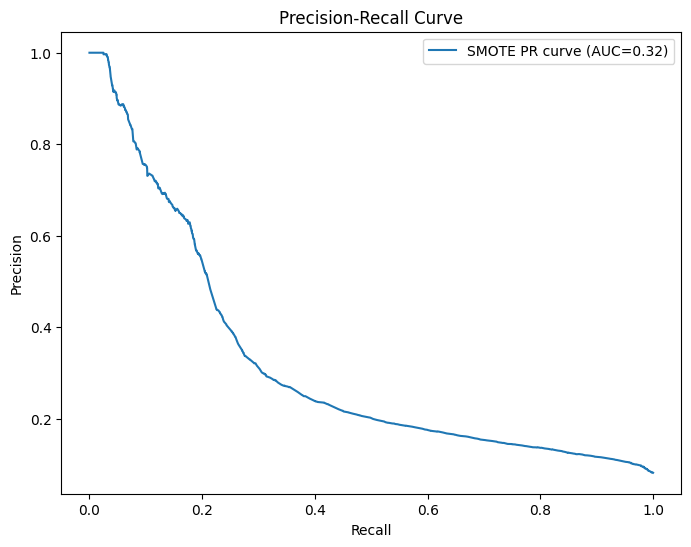

In [21]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_smote)

# Calculate the area under the PR curve
pr_auc = auc(recall, precision)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'SMOTE PR curve (AUC={pr_auc:.2f})')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

The curve is a method for visualising the trade off between precision and recall, displaying how catching more positives means that precision drops.

In our curve precision drops sharply as our low recall numbers rise which is reflected in our low AUC (area under the curve) value of **0.32**. This validates that we can choose high precision or high recall but not at the same time.

To choose the best threshold to use for our model lets conduct some threshold tuning and use the F1 metric as a decision factor, looking at the balance of precision and recall.

## 11. Threshold Tuning

Logistic regression outputs a probability score between 0 and 1, which represents the model’s estimated likelihood that a company will file its accounts late. The default decision threshold of 0.50 assumes equal misclassification costs and balanced classes. However, we have a highly imbalanced dataset as late filing is a minority class **(8.2%)**. Therefore, using the default threshold leads to high recall but extremely low precision for the positive class, producing an excessive number of false positives (those who the model claims will file late but who in fact don't).

To address this we perform threshold tuning to explore the trade‑off between precision and recall across a range of probability cut‑offs. We will evaluate different thresholds starting with 0.50 to show that our original SMOTE used this threshold as we get the same numbers here. Then increasing in increments of 0.05 until 0.80 (0.55, 0.60, 0.65, 0.70, 0.75, 0.80).

For each threshold, precision, recall, F1‑score, and confusion‑matrix counts are re-calculated using the model’s predicted probabilities on the test set.

Then the results are displayed in a dataframe for comparison.

In [22]:
thresholds = [0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]      # set the thresholds you would like to use
results = []

for t in thresholds:
    y_pred_t = (y_prob_smote >= t).astype(int)

    prec = precision_score(y_test, y_pred_t)
    rec = recall_score(y_test, y_pred_t)
    f1 = f1_score(y_test, y_pred_t)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_t).ravel()

    results.append({
        "threshold": t,
        "precision": prec,
        "recall": rec,
        "F1": f1,
        "TP": tp,
        "FP": fp,
        "FN": fn,
        "TN": tn
    })

threshold_df = pd.DataFrame(results)
threshold_df


,threshold,precision,recall,F1,TP,FP,FN,TN
0,0.50,0.143794,0.755519,0.241605,17077,101683,5526,151049
1,0.55,0.163498,0.654072,0.261604,14784,75639,7819,177093
2,0.60,0.191890,0.527142,0.281359,11915,50178,10688,202554
3,0.65,0.269560,0.355307,0.306550,8031,21762,14572,230970
4,0.70,0.336961,0.276689,0.303865,6254,12306,16349,240426
5,0.75,0.557627,0.195859,0.289896,4427,3512,18176,249220
6,0.80,0.634553,0.173384,0.272351,3919,2257,18684,250475


Our goal is to choose the probability cut-off that gives the best balance between precision and recall for our problem, which is to identify as many late-filing companies as possible. That means that recall and F1 are our key metrics as precision is less important. Missing the opportunity to identify late-filers is worse than mislabelling a compliant company and adding the administrative costs of validating that they were in fact not a late-filer. 

Our results show a clear pattern, that lower thresholds **(0.5 - 0.60)** produced higher recalls **(0.527+)** but very low precision **(0.14-0.19)**, meaning the model identified many late filers but at the cost of a large number of false alarms **(FP 50k-102k)**. Increasing the threshold improved precision but reduced recall. At **0.8**, precision rose to **0.63**, but recall fell to **0.17**, indicating that the model only flagged cases where it was extremely confident, missing the majority of late filers.

At a threshold of **0.65** the F1 score is the highest **(~0.307)** meaning that this threshold provided the most balanced performance. At this level precision was **~0.27**, recall was **~0.36** and false positives were **~21.8k**. This threshold still catches over half of all late filers while reducing false positives significantly compared to the default threshold of **0.50**.

This threshold also aligned with the “elbow” of the precision–recall curve, where increases in precision begin to result in large losses in recall. Selecting **0.65** therefore represents a sensible compromise between identifying late filers and maintaining an acceptable false‑positive rate.

Overall threshold tuning highlights the difficulty in choosing what is most important to a model. Is success based on precision (ensuring a higher proportion of the predicted late filers are correctly identified but identifying fewer late filers) or is it based on recall (ensuring more late filers are predicted but also accepting that a higher proportion of them will be flagged incorrectly).

Let's look at this visually to make a finaly decision before interpretting coefficients.

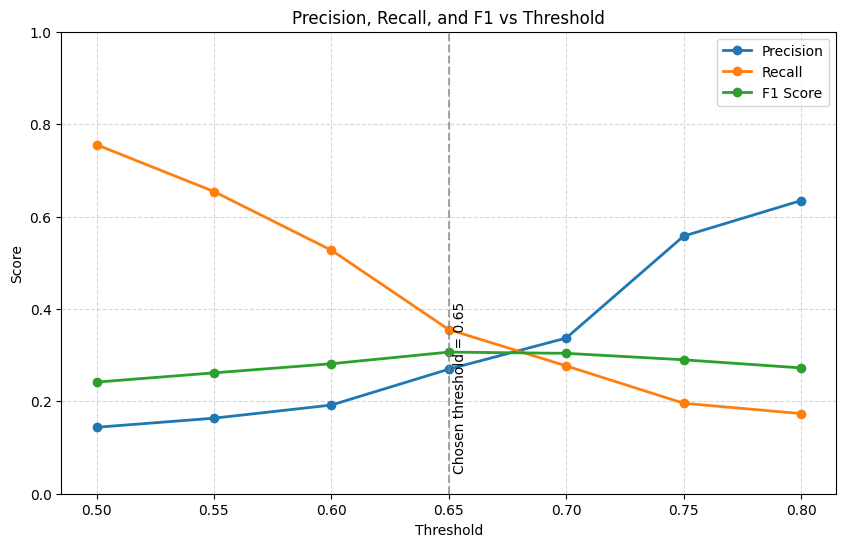

In [23]:

thresholds = threshold_df["threshold"]
precisions = threshold_df["precision"]
recalls = threshold_df["recall"]
f1s = threshold_df["F1"]

plt.figure(figsize=(10, 6))

plt.plot(thresholds, precisions, marker='o', label='Precision', linewidth=2)
plt.plot(thresholds, recalls, marker='o', label='Recall', linewidth=2)
plt.plot(thresholds, f1s, marker='o', label='F1 Score', linewidth=2)

# Optional: highlight your chosen threshold (e.g., 0.70)
chosen = 0.65
plt.axvline(chosen, color='grey', linestyle='--', alpha=0.7)
plt.text(chosen + 0.002, 0.05, f"Chosen threshold = {chosen}", rotation=90)

plt.title("Precision, Recall, and F1 vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()

plt.show()


This graph shows the precision, recall and F1 scores for the thresholds calculated above, along with the chosen threshold from above. The threshold of **0.65** provided the most balanced performance as demonstrated by the peak in the green F1 score line. This threshold aligns with the "elbow" of the precision–recall curve plotted earlier and represents the most appropriate operating point for this model.

The best option is so use case dependent that options should be presented to stakeholders, for purposes of this analysis **0.65** will be used and we move on to interpretting coefficients. 

## 11. Interpretation of Coefficients.
Here we look at which variables increase/decrease risk. <br>
This converts to odds ratios for interpretation.


In [24]:
ohe_features = pipeline_smote.named_steps['preprocessor'] \
.named_transformers_['cat'] \
.get_feature_names_out(categorical_cols)

all_features = numeric_cols + list(ohe_features)

coefficients = pipeline_smote.named_steps['model'].coef_[0]

coef_df = pd.DataFrame({
    'feature': all_features,
    'coefficient': coefficients,
    'odds_ratio': np.exp(coefficients)
}).sort_values(by='odds_ratio', ascending=False)

coef_df

,feature,coefficient,odds_ratio
6,company_category_PLC & OTHER,6.749246,853.415404
4,company_category_LTD,5.560559,259.968222
5,company_category_LTD BY GUARANTEE/CIC,4.804771,122.091567
23,industry_UNKNOWN,4.298936,73.621406
25,registered_country_UNKNOWN,1.544873,4.687375
9,company_age_when_acc_due_2–5,0.140310,1.150631
0,psc_count,0.061295,1.063212
2,has_foreign_psc,0.043869,1.044846
22,industry_Transport & Storage,0.005538,1.005554
10,company_age_when_acc_due_5–10,-0.043488,0.957444


- Risk Factors (features) that increase the odds of filing late have positive coefficients and odds ratio > 1. We have 9 of these in our model.
- Risk Factors (features) that decrease the odds of filing late have negative coefficients and odds ratio < 1. We have 17 of these in our model.

**Top 5 Biggest Risk Factors:** (those that increase the odds of late filing the most)
These have the highest odds ratios, meaning that they push the model strongly towards predicting “late”.
*1-3. Company Category:  PLC & OTHER, LTD or LTD BY GUARANTEE/CIC*
**Meaning:** Companies with these company categories are more likely to file late than companies outside of these company categories. Public Limited Companies tend to be larger, more comples organisations with heavier reporting requirements which may lead to delays. LTD companies make up the majority of UK companies, and many are small or inactive, which may lead to poor compliance. LTD by guarantee / CIC tend to often be charities, clus or community groups possibly with limited administrative resources which may lead to late filing.
*4-5. Industry: Unknown and Registered Country: UNKNOWN*
**Meaning:** The industry in which the company operates/the country where the company is registered is unknown.
**Interpretation:** Missing data may be due to poor record keeping or low engagement with compliance.

**Bottom 5 Risk Factors:** (those that decrease the odds of filing late the most)
....

TODO: Finish writing this when the model is finalised with new data and all code re-run through it.

TODO: Also edit this.
Company category and missing information are the strongest predictors of late filing, while older companies and regulated or professional industries are the least likely to file late.

Next plot a feature importance graph which plots the absolute logistic regression coefficients and ranks the featues by importance. This gives a visual representation of which features are the most important to a model regardless of whether they increase or decrease the risk of a company filing late.

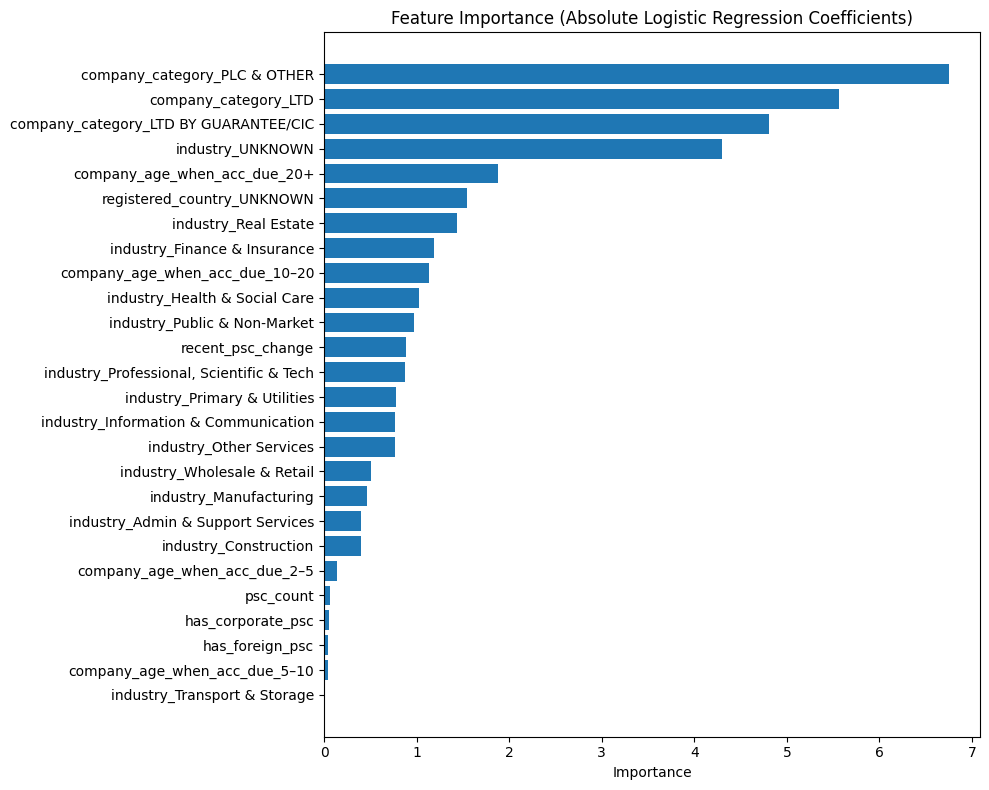

In [25]:
# Shows which features have the strongest influence on predictions.
coef_df_sorted = coef_df.copy().sort_values(by='coefficient', key=np.abs, ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(coef_df_sorted['feature'], coef_df_sorted['coefficient'].abs())
plt.title("Feature Importance (Absolute Logistic Regression Coefficients)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

TODO: Edit this when the model is finalised.
Top 5 Most Influential Features (push the model hardest)
These features have the biggest absolute impact on the model’s predictions — they’re the strongest signals.
1. Recent PSC change
If a company recently changed who controls it, the model sees this as a red flag.
It’s the strongest signal of potential late filing.

2. Has a foreign PSC
If someone controlling the company is based abroad, the model sees this as a risk.
International admin tends to be slower and more complex.

3. Has a corporate PSC
If another company controls this one, it adds layers of admin.
The model learns that corporate ownership often means slower filings.

4. PSC count
More people or entities in control = more complexity.
The model sees this as increasing the chance of missing deadlines.

5. Industry: Wholesale & Retail
Companies in retail or wholesale are more likely to file late.
These sectors often have high churn and small admin teams.


Bottom 5 Least Influential Features (weakest signals)
These features have the smallest absolute coefficients — they barely nudge the model’s decision.
1. Company category: LTD
Standard private limited companies are very common.
The model doesn’t learn much from this — it’s a neutral baseline.

2. Company category: LTD by Guarantee / CIC
Non‑profits and community interest companies don’t show strong filing patterns.
The model sees them as low‑impact.

3. Company category: PLC & Other
Public companies are rare in your dataset.
The model doesn’t rely on this feature much.

4. Company age: 10–20 years
Mid‑life companies are stable, but not extreme.
The model sees this age group as average — not risky, not safe.

5. Company age: 20+ years
Very old companies are reliable, but the model already learns that from other features.
This age group doesn’t add much extra signal.


The most influential features in the model relate to ownership complexity and industry sector, while company type and age have weaker effects and serve more as background context than strong predictors.

## 12. Into Production

In a production environment, the model would receive new company records and automatically apply the same preprocessing steps used during training via the scikit‑learn pipeline. The logistic regression model would then generate a probability of late filing for each company. A threshold of **0.65** would be applied to convert this probability into a binary risk flag, allowing compliance teams to prioritise companies most likely to file late. The system could be integrated into a batch ETL workflow, an API‑driven service, or a dashboard, and would be retrained periodically to reflect changes in filing behaviour.

As a stratified sample of the original population was used in the training of the model we have a large population of data unseen by the model to use in this step.
- Starting population = ~5.5million;
- 25% sample data ~1.375million (this data was used in the model building, this is the test/train data)
- 75% discarded data = ~4.125million (this data was not used at any stage of the model development and is therefore treated as unseen data for the purposes of applying the model to new data).

Note: This is not "future" data and ideally fresh data could be sourced with new companies not in the downloaded data at all however for the purposes of this analysis the discarded data will be used.

Next we use df_discard and run the model on that data to produced a risk score for all companies that weren't in the sample dataset and segment into risk bandings.
High Risk: > 0.7
Medium Risk: 0.4-0.7
Low Risk: <0.4
or top 1000 most risky companies, top 10% of risky companies.

Then look at the characteristics of the group - what are the dominating features?
Examples: do they have more foreign/corporate pscs? are they younger companies? which industries do they fall into (e.g. retail?)

In [27]:
# Rename the data for clarity of purpose
df_unseen = df_discard.copy()

df_unseen.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4130021 entries, 2698968 to 3312561
Data columns (total 9 columns):
 #   Column                    Dtype   
---  ------                    -----   
 0   company_category          category
 1   company_age_when_acc_due  category
 2   industry                  category
 3   registered_country        category
 4   psc_count                 int64   
 5   has_corporate_psc         int8    
 6   has_foreign_psc           int8    
 7   recent_psc_change         int8    
 8   overdue                   int8    
dtypes: category(4), int64(1), int8(4)
memory usage: 94.5 MB


In [28]:
# separate the features from the target
x_unseen = df_unseen.drop(columns=[target])     # define x_unseen which contains all predictor/feature variables.
y_unseen = df_unseen[target]                    # define y_unseen which contains only the target variable

In [31]:
# Generate predicted probabilities by passing the unseen data through our chosen pipeline
df_unseen['late_prob'] = pipeline_smote.predict_proba(x_unseen)[:,1]

In [33]:
# Apply the tuned threshold from earlier of 0.65
Threshold = 0.65
df_unseen['predicted_late'] = (
    df_unseen['late_prob'] >= Threshold
).astype(int)

In [42]:
df_unseen.dtypes

company_category            category
company_age_when_acc_due    category
industry                    category
registered_country          category
psc_count                      int64
has_corporate_psc               int8
has_foreign_psc                 int8
recent_psc_change               int8
overdue                         int8
late_prob                    float64
predicted_late                 int64
risk_band                     object
dtype: object

In [44]:
# Create risk bandings discussed above.
top_10pc_cutoff = df_unseen['late_prob'].quantile(0.90) # Get the top 10 percent of companies most likely to file late
top_20pc_cutoff = df_unseen['late_prob'].quantile(0.80) # Get the top 20 percent of companies most likely to file late
df_unseen['risk_band'] = 'Low'                          # Generate a new column called risk which has a default value of "Low"

 # Redefine the risk band for the riskiest 10% of companies as High.
df_unseen.loc[df_unseen['late_prob'] >= top_10pc_cutoff, 'risk_band'] = 'High'

# Redefine the risk band for the companies in the top 20pc of riskiest companies but lower than the top 10% of riskiest companies as Medium.
df_unseen.loc[
    (df_unseen['late_prob'] >= top_20pc_cutoff) & (df_unseen['late_prob'] < top_10pc_cutoff), 'risk_band'] = 'Medium'


In [49]:
# counts per band
print(df_unseen['risk_band'].value_counts())

# percentages per band
print(df_unseen['risk_band'].value_counts(normalize=True)*100)

# Average probability per band
print(df_unseen.groupby('risk_band')['late_prob'].mean())

risk_band
Low       3302422
High       421184
Medium     406415
Name: count, dtype: int64
risk_band
Low       79.961385
High      10.198108
Medium     9.840507
Name: proportion, dtype: float64
risk_band
High      0.746709
Low       0.345473
Medium    0.629763
Name: late_prob, dtype: float64


In [53]:
# Profile the high-risk group

high_risk = df_unseen[df_unseen['risk_band'] == 'High'] # Pull out the high risk population

# Get the distribution of ket features.
print(high_risk['company_category'].value_counts(normalize=True))
print(high_risk['industry'].value_counts(normalize=True))

company_category
LTD                     0.983368
LTD BY GUARANTEE/CIC    0.007935
LLP                     0.004414
PLC & OTHER             0.004283
Name: proportion, dtype: float64
industry
Accommodation & Food               0.332852
Transport & Storage                0.170636
Construction                       0.135971
Wholesale & Retail                 0.101647
Admin & Support Services           0.078837
Manufacturing                      0.043902
UNKNOWN                            0.027803
Professional, Scientific & Tech    0.027522
Other Services                     0.024346
Information & Communication        0.018980
Real Estate                        0.012394
Finance & Insurance                0.009324
Health & Social Care               0.006273
Public & Non‑Market                0.005594
Primary & Utilities                0.003920
Name: proportion, dtype: float64


TODO: Write more notes on this section after conducting going back through all scripts and making changes already flagged.

If company_number had been retained in the model ready data from the EDA and cleansing script then I could produce a risk population to save off for reporting and further analysis, however as this is being published to github I chose to remove company number for the purposes of this analysis.